In [66]:
from dotenv import load_dotenv
load_dotenv()
import os

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-20b")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User says "Hello". Likely they want a greeting. We\'ll respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_time': 0.040913177, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.00341953, 'prompt_tokens_details': None, 'queue_time': 0.049845689, 'total_time': 0.044332707}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a04ca5-bd65-7f50-9d07-ce38ea3478af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 37, 'total_tokens': 109, 'output_token_details': {'reasoning': 17}})

### Analyst With Human Loop

In [67]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

class Analyst(BaseModel):
    affiliation: str = Field(description="Primary affiliation of the analyst.",)
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.",)
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.",)

class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [68]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [69]:
def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = llm.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [70]:
def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass

In [71]:

def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

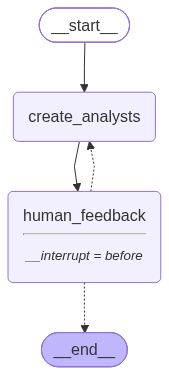

In [72]:
# Add nodes and edges 
builder = StateGraph(GenerateAnalystsState)
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [73]:
# Input
max_analysts = 3 
topic = "The benefits of adopting LangGraph as an agent framework"
thread = {"configurable": {"thread_id": "1"}}

In [74]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    analysts=event.get("analysts",'')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 


Name: Dr. Maya Patel
Affiliation: MIT CSAIL
Role: Integration Architect
Description: Dr. Patel focuses on how LangGraph can be integrated into existing LLM pipelines, APIs, and data sources. She is concerned with interoperability standards, backward compatibility, and the ability to plug into heterogeneous systems. Her motive is to maximize adoption by ensuring smooth transitions for enterprises.
--------------------------------------------------
Name: Dr. Luis Gomez
Affiliation: Stanford AI Lab
Role: Systems Performance Engineer
Description: Dr. Gomez examines LangGraph’s scalability, latency, and resource utilization in large‑scale deployments. He evaluates benchmarks, fault tolerance, and cost‑efficiency. His goal is to demonstrate that LangGraph can handle millions of concurrent agents without performance degradation.
--------------------------------------------------
Name: Alex Chen
Affiliation: GitHub
Role: Product Manager & Community Lead
Description: Alex champions developer ex

In [75]:
state=graph.get_state(thread)

In [76]:
state.next

('human_feedback',)

In [77]:
# We now update the state as if we are the human_feedback node
user_input=input("Tell me how you want to update the state:")
graph.update_state(thread, {"messages": user_input}, as_node="human_feedback")

for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Maya Patel
Affiliation: MIT CSAIL
Role: Integration Architect
Description: Dr. Patel focuses on how LangGraph can be integrated into existing LLM pipelines, APIs, and data sources. She is concerned with interoperability standards, backward compatibility, and the ability to plug into heterogeneous systems. Her motive is to maximize adoption by ensuring smooth transitions for enterprises.
--------------------------------------------------
Name: Dr. Luis Gomez
Affiliation: Stanford AI Lab
Role: Systems Performance Engineer
Description: Dr. Gomez examines LangGraph’s scalability, latency, and resource utilization in large‑scale deployments. He evaluates benchmarks, fault tolerance, and cost‑efficiency. His goal is to demonstrate that LangGraph can handle millions of concurrent agents without performance degradation.
--------------------------------------------------
Name: Alex Chen
Affiliation: GitHub
Role: Product Manager & Community Lead
Description: Alex champions developer ex

In [78]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Maya Patel
Affiliation: MIT CSAIL
Role: Integration Architect
Description: Dr. Patel focuses on how LangGraph can be integrated into existing LLM pipelines, APIs, and data sources. She is concerned with interoperability standards, backward compatibility, and the ability to plug into heterogeneous systems. Her motive is to maximize adoption by ensuring smooth transitions for enterprises.
--------------------------------------------------
Name: Dr. Luis Gomez
Affiliation: Stanford AI Lab
Role: Systems Performance Engineer
Description: Dr. Gomez examines LangGraph’s scalability, latency, and resource utilization in large‑scale deployments. He evaluates benchmarks, fault tolerance, and cost‑efficiency. His goal is to demonstrate that LangGraph can handle millions of concurrent agents without performance degradation.
--------------------------------------------------
Name: Alex Chen
Affiliation: GitHub
Role: Product Manager & Community Lead
Description: Alex champions developer ex

In [79]:
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1a3842-088e-6717-8003-27067e64de9d'}}

In [80]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [81]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

In [82]:
final_state.next

()